# Modelos de regresión lineal regularizados

La regularizaciòn es una estrategia para reducir la complejidad de los modelos a través del control del tamaño de los coeficientes. Con esta estrategia se busca reducir la **varianza** del modelo, sin aumentar su **sesgo**.

In [8]:
import matplotlib.pyplot as plt
import numpy as np

Nuevamente, vamos a trabajar con un dataset sintético con una solo 2 variables, una de entrada, y otra de salida.

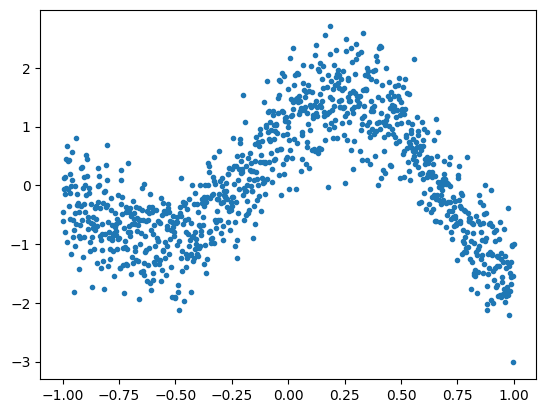

In [9]:
#Se genera un conjunto de datos con ruido(datos atipicos)
X = np.linspace(-1, 1, 1000)
ruido = np.random.normal(0, 0.5, 1000)
y = np.sin(4*X) + np.cos(3*X) + ruido
X = X.reshape(-1,1)
plt.plot(X,y, '.')

Vamos a encontrar el modelo polinómico que menor error tenga:

* Aqui vamos a obtener el polinomio que mejor se ajusta a los datos, y luego se muestra la grafica del grado del polinomio vs el error del polinomio(el polinomio nunca se va a justar el 100% con lo datos originales a esa diferencia se le llama error). En esta grafica se puede ver que despues de cierto grado del polinomio ya el error es demacioda grande. (ya tiene mucho nivel de dificultad el modelo).  

Text(0, 0.5, 'RMSE')

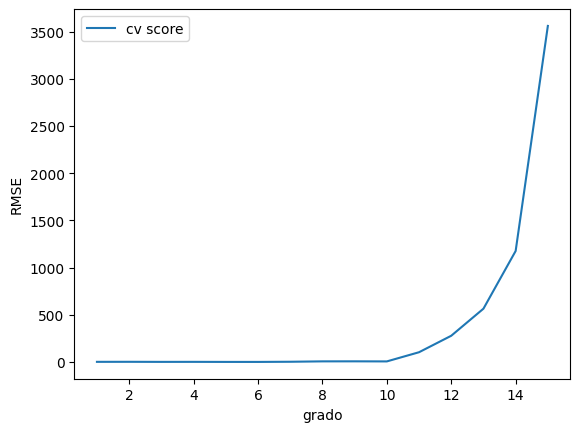

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures

degrees = range(1,16)
mean_scores_cv = []
for degree in degrees:
  poly = PolynomialFeatures(degree = degree, include_bias=False)
  X_p = poly.fit_transform(X)
  score = cross_val_score(estimator = LinearRegression(), X=X_p , y=y, cv=5,
                          scoring='neg_root_mean_squared_error')
  mean_scores_cv.append(-score.mean())
plt.plot(degrees, mean_scores_cv, '-', label='cv score')
plt.legend()
plt.xlabel('grado')
plt.ylabel('RMSE')

In [11]:
mean_scores_cv #Errores obtenidos para cada grado del polinomio.(desde 0 hasta infinito)

[np.float64(1.5080443564644832),
 np.float64(1.932113166290187),
 np.float64(1.1143572011669867),
 np.float64(1.426134634000156),
 np.float64(0.7800457105486448),
 np.float64(0.6861281107176301),
 np.float64(2.432017047616449),
 np.float64(6.587648515851205),
 np.float64(6.987488605258069),
 np.float64(6.051302533843508),
 np.float64(103.39055290833343),
 np.float64(277.9655431882604),
 np.float64(564.8405548183833),
 np.float64(1176.3681261073027),
 np.float64(3561.4358179240908)]

* Se muestra cual fue el error mas pequeño(el mejor RMSE), y con cual grado del polinomio se obtuvo este error. 

In [14]:
print(f'El mejor RMSE es {np.min(mean_scores_cv):.3f}, obtenido con un grado de polinomio {degrees[np.argmin(mean_scores_cv)]}.')  # noqa: E501

El mejor RMSE es 0.686, obtenido con un grado de polinomio 6.


* Aqui se muestra la grafica que se genera a partir del polinomio encontrado anteriormente con el menor error(es en color rojo).

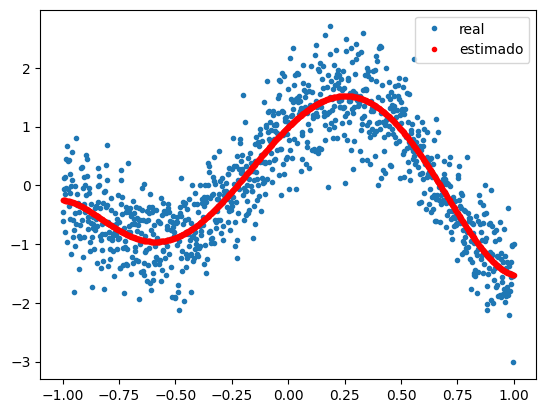

In [15]:
poly = PolynomialFeatures(degree = degrees[np.argmin(mean_scores_cv)], include_bias=False)
X_p = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_p, y)
y_est = model.predict(X_p)

plt.plot(X, y, '.', label ='real')
plt.plot(X, y_est, '.r', label = 'estimado')
plt.legend();

Los coeficientes de este modelo son:

* Aqui se muestran los coeficientes del polinomio encontrado

In [16]:
print(f'Coeficients: {model.coef_}')
print(f'Intercept: {model.intercept_}')

Coeficients: [ 3.79282961 -4.82235073 -8.9084161   4.17290394  4.48017659 -1.23434461]
Intercept: 0.9949922216105122


# Modelo Ridge

Ahora vamos a aplicar modelos regularizados para ver si obtenemos un mejor desempeño.

Estos modelos tienen un hiperparámetro llamado $\lambda$ con el que se controla cuanto reducir la complejidad. $\lambda$ puede tomar valores en el rango $[0, \infty)$, y mientras más grande sea más reduce el tamaño de los coeficientes y más reduce la complejidad del modelo.

En Scikit Learn estos modelos están implementados en las clases Ridge() y Lasso(), y el factor de regularización se llama alpha.

In [19]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

poly = PolynomialFeatures(degrees[np.argmin(mean_scores_cv)], include_bias=False)
X_p = poly.fit_transform(X)

model = Ridge(alpha=1)

score = cross_val_score(model, X_p, y, cv=5, scoring='neg_root_mean_squared_error')
print(f'RMSE de validación con alpha = 1: {-score.mean():.3f}')
model.fit(X_p, y)
print(f'Coeficientes: {model.coef_}')
print(f'Intercept: {model.intercept_}')

RMSE de validación con alpha = 1: 0.797
Coeficientes: [ 2.68359049 -3.23922649 -4.23771876  0.39479851  0.51347766  1.13341267]
Intercept: 0.884590993336187


Vamos a evaluar este modelo por validación cruzada para tener una aproximación más realista de su verdadero **error de generalización**. Vamos a probar nuestro modelo con diferentes valores de $\lambda$.

Aqui los valores de  $\lambda$ se los estamos dando en una lista generada por nosotros(aqui es solo un ejemplo). 

In [20]:
from sklearn.model_selection import cross_val_score

poly = PolynomialFeatures(degrees[np.argmin(mean_scores_cv)], include_bias=False)
X_p = poly.fit_transform(X)

alphas = [0, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
for alpha in alphas:
  model = Ridge(alpha = alpha)
  score = cross_val_score(model, X_p, y, cv=5, scoring='neg_root_mean_squared_error')
  print(f'RMSE de validación con alpha = {alpha}: {-score.mean():.3f}')
  model.fit(X_p, y)
  print(f'Coeficientes: {model.coef_}')

RMSE de validación con alpha = 0: 0.686
Coeficientes: [ 3.79282961 -4.82235073 -8.9084161   4.17290394  4.48017659 -1.23434461]
RMSE de validación con alpha = 0.001: 0.642
Coeficientes: [ 3.79005895 -4.81001254 -8.89643973  4.13834512  4.46985585 -1.21008619]
RMSE de validación con alpha = 0.01: 0.773
Coeficientes: [ 3.76550321 -4.7073532  -8.79032509  3.85137692  4.37842436 -1.00890089]
RMSE de validación con alpha = 0.1: 1.062
Coeficientes: [ 3.5524457  -4.13180839 -7.87215351  2.27567086  3.58849081  0.08134503]
RMSE de validación con alpha = 1: 0.797
Coeficientes: [ 2.68359049 -3.23922649 -4.23771876  0.39479851  0.51347766  1.13341267]
RMSE de validación con alpha = 10: 1.250
Coeficientes: [ 1.72322698 -1.91526893 -1.47690837 -0.31391714 -1.21326493  0.38466287]
RMSE de validación con alpha = 100: 1.236
Coeficientes: [ 0.592954   -0.73386049 -0.348153   -0.4378306  -0.45626506 -0.2669411 ]
RMSE de validación con alpha = 1000: 1.234
Coeficientes: [ 0.10071959 -0.15997202 -0.0277247

Se observa que el error de validación baja cuando se incrementa el valor de $\lambda$, pero hasta cierto punto, porque después vuelve a subir.

Por otra parte, el tamaño de los coeficientes si baja a medida que se aumenta el valor de $\lambda$.

# Sintonización de hiperparámetros

Dado que $\lambda$ puede tomar un rango muy amplio de valores (desde 0 hasta $\infty$), encontrar el valor óptimo con el que se obtenga el **menor error de validación** es un gran desafío.

Lo que se puede hacer es probar con un gran número de valores, y de estos valores seleccionar el que de mejores resultados. Este proceso se conoce como **sintonización de hiperparámetros**.

Otro problema aquí es que para saber que valor del hiperparámetro da mejores resultados se debería evaluar con datos diferentes a los datos con los que se entrena el modelo, pero estos a la vez deberían ser diferentes a los datos con los que se evalúa el modelo ya ajustado y con los hiperparámetros seleccionados. Esto implica que de nuestro dataset debemos sacar 3 subconjuntos:
- Un subconjunto para entrenar el modelo con cada hiperparámetro.
- Un subconjunto para evaluar el modelo ajustado con cada hiperparámetro.
- Un subconjunto para evaluar el modelo ajustado con el hiperparámetro ya seleccionado.

Estos 3 subconjuntos se conocen respectivamente como conjunto de datos de **entrenamiento**, **validación** y **prueba**. A esto hay que añadir que lo idela sería entrenar y validar cada hiperparámetro con varios conjuntos de datos, para evitar sesgo y saber que tanta varianza tiene.

Dado todo lo anterior, habría que hacer una primera partición de los datos, antes de hacer cualquier procesamiento a la matriz de características y de entrenar los modelos. Esto es Scikit Learn se puede hacer con el método train_test_split. De esta manera nos quedaría un subconjunto de datos para sintonizar los hiperparámetros, que llamaremos por ahora **dataset de entrenamiento**, y otro para evaluar los modelos con los hiperparámetros ya sintonizados y ajustados, que llamaremos **dataset de prueba**.



* Aqui se dividen los datos en los datos de entramiento y los datos de prueba

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=72, train_size=0.8)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (800, 1)
Tamaño del conjunto de prueba es: (200, 1)


Con el dataset de prueba no se hará nada hasta el final.

Ahora, la obtención de los subconjuntos de entrenamiento y validación para sintonizar hiperparámetros puede hacerse por validación cruzada. Aunque el método cross_val_score nos serviría, existen en Scikit Learn clases especializadas para hacer sintonización de hiperparámetros por validación cruzada, uno de los cuales es **GridSearchCV**.

* Con este metodo lo que queremos es minimizar la variaza que es la diferencia entre el error que se obtuvo cuando se entreno el modelo y el error cuando se probo el modelo. Y tambien queremos minimizar el sesgo del modelo. entoces Para poder lograr que se reduzcan de forma equilibrada estas dos variables se multiplica la varianza por $\lambda$. Si le damos mas importancia a que baje la varianza se pone labda >= 1, si queremos darle prioriadad a sesgo se pone 0<= labda < 1,pero si queremos que no le de mayor importancia a ninguno se pone labda = 1. Pero esto no lo ponemos nosotros se hace con esta funcion: GridSearchCV.

* Aqui lo que hacemos es decirle a codigo que queremos que nos genere al azar 100 valores distintos que este entre 10^-4 y 10^4 para que obtengamos todos los rangos posibles y deverdad escja el que sea mas comveniente para los datos como tal.

* Antes dividimos los datos entre los de entrenamoento y los de prueba, aqui el codigo coje los de entrenamiento y los divide en 5 grupos distintos para cada valor posible de labda y prueba el labda cuando termina con los 5 grupos de datos el les calcula el error promedio, el error promedio mas bajito ese labda sera el labda del polinomio de los datos. 

In [20]:
from sklearn.model_selection import GridSearchCV

poly = PolynomialFeatures(degrees[np.argmin(mean_scores_cv)], include_bias=False)
X_train_p = poly.fit_transform(X_train)

alpha = np.logspace(-4, 4, 100)# pasando 100 valores entre 10^-4 y 10^4 

grid = dict(alpha = alpha)

grid_search = GridSearchCV(
    estimator=model, 
    param_grid=grid, 
    scoring='neg_root_mean_squared_error'
    )

grid_search.fit(X_train_p, y_train)

print(
    f"Mejor RMSE obtenido fue {-grid_search.best_score_:.3f}, "
    f"con lambda de {grid_search.best_params_}."
)

Mejor RMSE obtenido fue 0.504, con lambda de {'alpha': np.float64(0.0013530477745798076)}.


**GridSearchCV**, y métodos similares, tienen una ventaja adicional sobre hacer CV de manera manual para sintonizar hiperparámetros, y es que **entregan el mejor modelo ya sintonizado y entrenado**. El mejor modelo se obtiene usando el atributo **best_estimator_**.

Con este, ya es posible hacer predicciones y evaluar el modelo con datos de prueba.

In [21]:
best_model = grid_search.best_estimator_
X_test_p = poly.fit_transform(X_test)
print(f'RMSE de prueba es {np.sqrt(mean_squared_error(y_test, best_model.predict(X_test_p))):.3}.')  # noqa: E501

RMSE de prueba es 0.444.


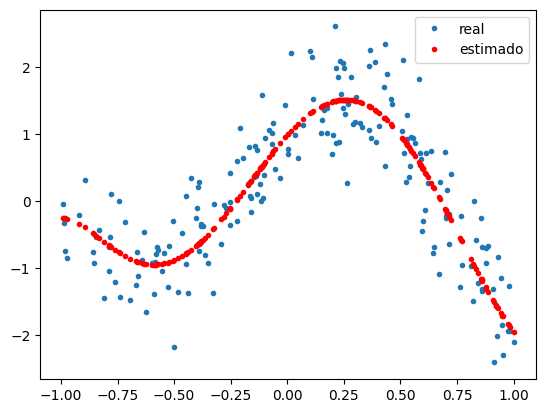

In [12]:
y_est = best_model.predict(X_test_p)
plt.plot(X_test, y_test, '.', label ='real')
plt.plot(X_test, y_est, '.r', label = 'estimado')
plt.legend();

Vemos que este modelo efectivamente tiene menor error. Los coeficientes de este modelo son:

In [13]:
print(f'Las pendientes de este modelo son: {best_model.coef_}')
print(f'El intercepto de este modelo es: {best_model.intercept_}')

Las pendientes de este modelo son: [ 3.75752762 -4.74478848 -8.56118756  4.32602523  3.95219087 -1.67547486]
El intercepto de este modelo es: 0.9895327007275047


En este caso, la disminución del tamaño de los coeficientes fue mínima, porque el mejor valor encontrado para $\lambda$ fue pequeño. Sin embargo, vemos que esto fue suficiente para mejorar el modelo.

# Ejercicio

Cargar el archivo 'auto-mpg.data', póngale nombre a las columnas de acuerdo a lo indicado en el archivo 'auto-mpg.names'.

Configure como índice la variable 'car_name'.

Haga un modelo de regresión Ridge que prediga la variable 'mpg' usando todas las demás variables disponibles como predictoras. Para esto haga una partición de los datos en subconjuntos de entrenamiento y prueba en una proporción 70/30, usando random_state=1.

Reporte el mejor valor de $\lambda$ encontrado, el RMSE de entrenamiento y el de prueba con este valor, el intercepto y los pesos del modelo.